In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# Set standard plotting style
plt.style.use('ggplot')
sns.set_palette("muted")

# ---------------------------------------------------------
# Define input pairs here. 
# Add new dictionaries to the list for future model evaluations.
# ---------------------------------------------------------
input_pairs = [
    # {
    #     "model_name": "CloudFormation (Deployable)",
    #     "result_file": "result/iacgod/DeepseekV4Flash_deployability.csv",
    #     "coverage_file": "result/iacgod/Coverage_DSV4_CFN_Dep.csv"
    # },
    # {
    #     "model_name": "CloudFormation (Security)",
    #     "result_file": "result/iacgod/DeepseekV4Flash_security.csv",
    #     "coverage_file": "result/iacgod/Coverage_DSV4_CFN_Sec.csv"
    # },
    {
        "model_name": "No Planner",
        "result_file": "result/iacgod/DeepseekV4Flash_sec_ablation_no_planner.csv",
        "coverage_file": "result/iacgod/Coverage_DSV4_Ablation_No_Planner.csv"
    },
    {
        "model_name": "No HyDE",
        "result_file": "result/iacgod/DeepseekV4Flash_sec_ablation_no_hyde.csv",
        "coverage_file": "result/iacgod/Coverage_DSV4_Ablation_No_HyDE.csv"
    },
    {
        "model_name": "No Remediation",
        "result_file": "result/iacgod/DeepseekV4Flash_sec_ablation_no_remediation.csv",
        "coverage_file": "result/iacgod/Coverage_DSV4_Ablation_No_Remediator.csv"
    }
]

In [14]:
merged_dataframes = {}

for pair in input_pairs:
    model = pair["model_name"]
    res_df = pd.read_csv(pair["result_file"])
    cov_df = pd.read_csv(pair["coverage_file"])
    
    # Merge based on row_number (using left join to keep base records)
    merged_df = pd.merge(res_df, cov_df, on="row_number", how="left")
    merged_dataframes[model] = merged_df
    
    print(f"Successfully merged {len(merged_df)} rows for {model}.")

Successfully merged 15 rows for No Planner.
Successfully merged 15 rows for No HyDE.
Successfully merged 15 rows for No Remediation.


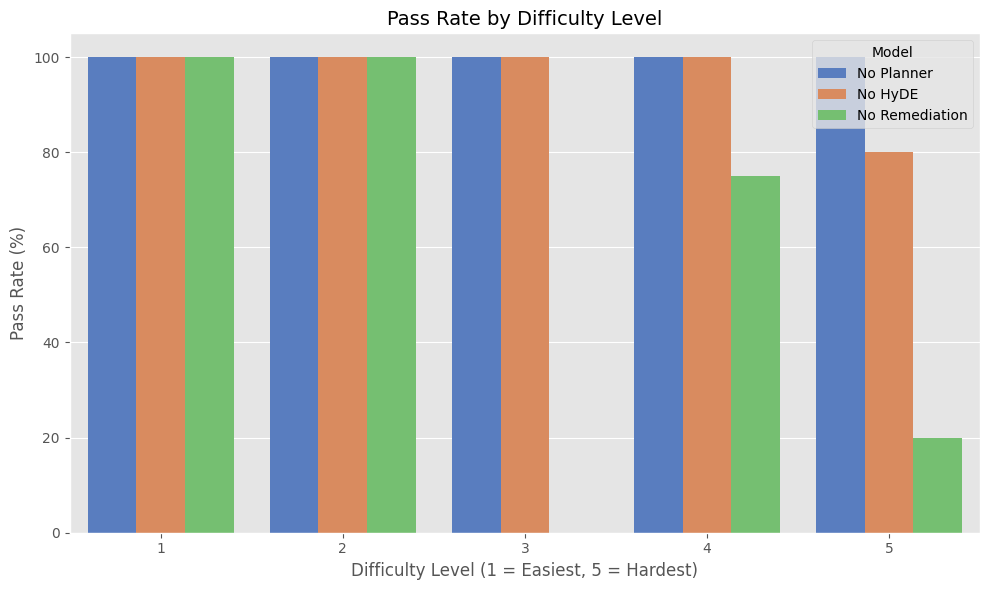

In [15]:
difficulty_stats = []

for model_name, df in merged_dataframes.items():
    if 'difficulty_level' in df.columns and 'final_validation_passed' in df.columns:
        # Calculate pass rate per difficulty level
        pass_rates = df.groupby('difficulty_level')['final_validation_passed'].mean() * 100
        
        for diff, rate in pass_rates.items():
            difficulty_stats.append({
                'Model': model_name,
                'Difficulty Level': diff,
                'Pass Rate (%)': rate
            })

if difficulty_stats:
    diff_df = pd.DataFrame(difficulty_stats)
    
    plt.figure(figsize=(10, 6))
    sns.barplot(data=diff_df, x='Difficulty Level', y='Pass Rate (%)', hue='Model')
    plt.title('Pass Rate by Difficulty Level', fontsize=14)
    plt.ylim(0, 105)
    plt.xlabel('Difficulty Level (1 = Easiest, 5 = Hardest)')
    plt.ylabel('Pass Rate (%)')
    plt.legend(title="Model")
    plt.tight_layout()
    plt.show()
else:
    print("Could not find 'difficulty_level' or 'final_validation_passed' columns.")

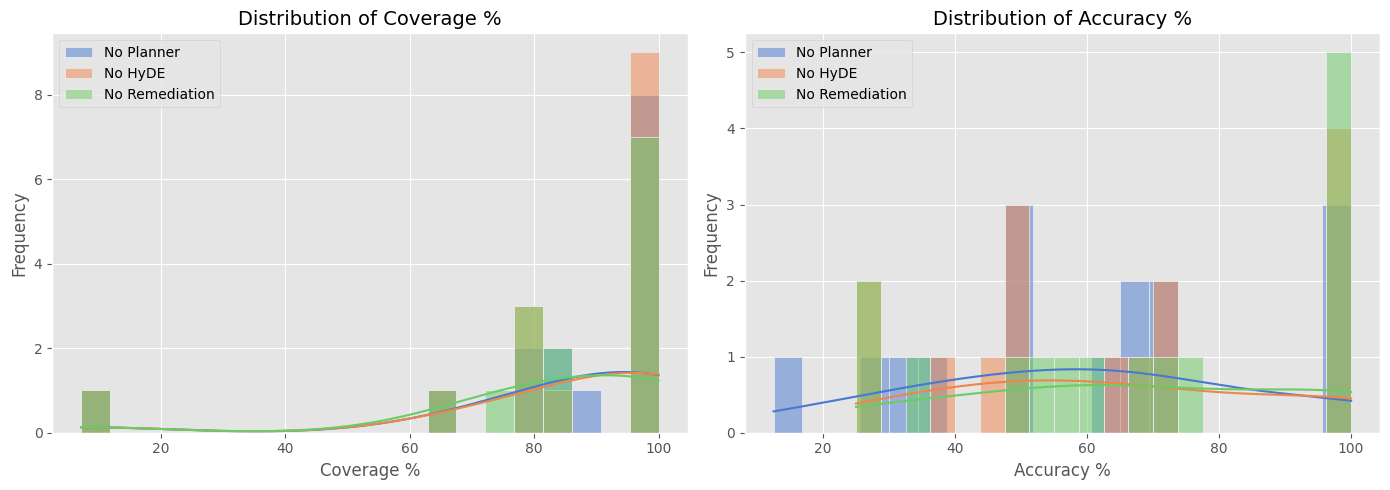

In [16]:
plt.figure(figsize=(14, 5))

for idx, (model_name, df) in enumerate(merged_dataframes.items()):
    # Subplot 1: Coverage %
    plt.subplot(1, 2, 1)
    sns.histplot(df['coverage_pct'].dropna(), bins=20, kde=True, label=model_name, alpha=0.5)
    plt.title('Distribution of Coverage %', fontsize=14)
    plt.xlabel('Coverage %')
    plt.ylabel('Frequency')
    plt.legend()
    
    # Subplot 2: Accuracy %
    plt.subplot(1, 2, 2)
    sns.histplot(df['accuracy_pct'].dropna(), bins=20, kde=True, label=model_name, alpha=0.5)
    plt.title('Distribution of Accuracy %', fontsize=14)
    plt.xlabel('Accuracy %')
    plt.ylabel('Frequency')
    plt.legend()

plt.tight_layout()
plt.show()

/var/folders/mr/k47n2bks0fs1y0cmq922vqbh0000gn/T/ipykernel_97047/1164442205.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_missing, y='Resource Type', x='Frequency', palette='Blues_r')


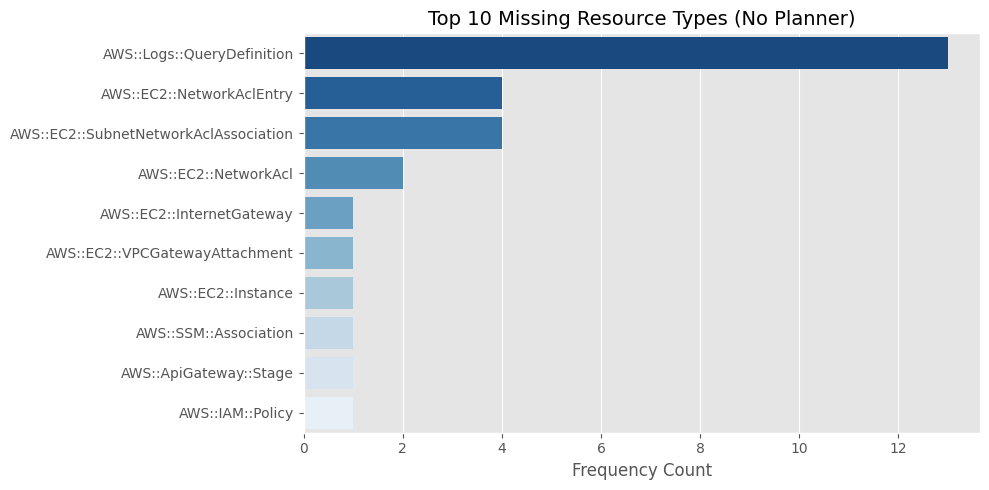

/var/folders/mr/k47n2bks0fs1y0cmq922vqbh0000gn/T/ipykernel_97047/1164442205.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_extra, y='Resource Type', x='Frequency', palette='Oranges_r')


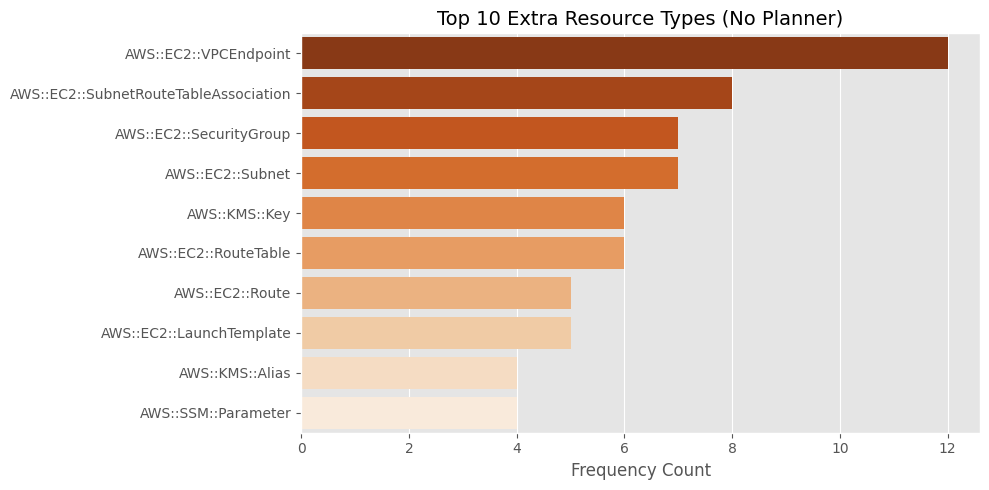

/var/folders/mr/k47n2bks0fs1y0cmq922vqbh0000gn/T/ipykernel_97047/1164442205.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_missing, y='Resource Type', x='Frequency', palette='Blues_r')


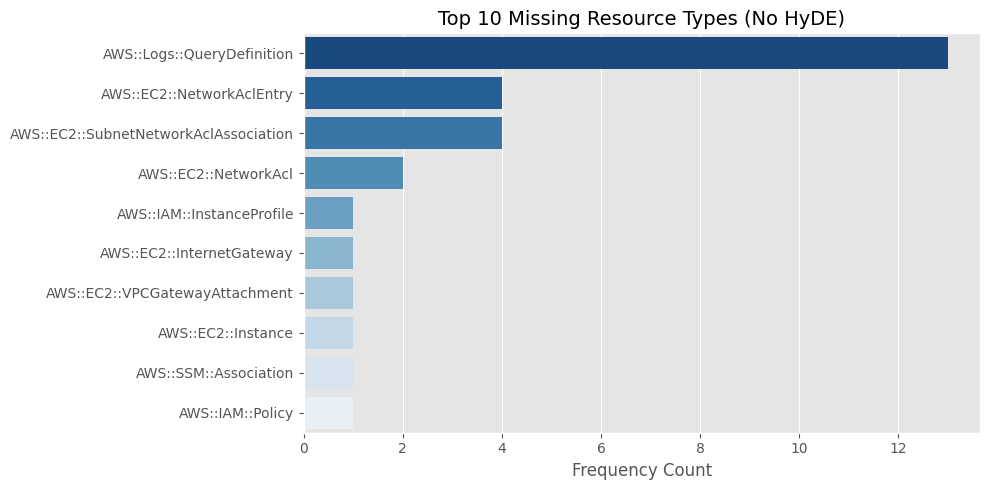

/var/folders/mr/k47n2bks0fs1y0cmq922vqbh0000gn/T/ipykernel_97047/1164442205.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_extra, y='Resource Type', x='Frequency', palette='Oranges_r')


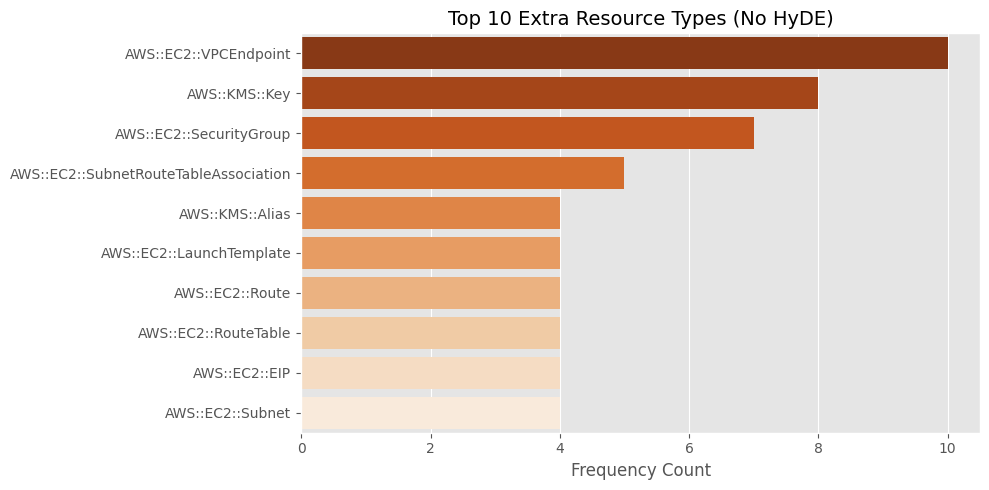

/var/folders/mr/k47n2bks0fs1y0cmq922vqbh0000gn/T/ipykernel_97047/1164442205.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_missing, y='Resource Type', x='Frequency', palette='Blues_r')


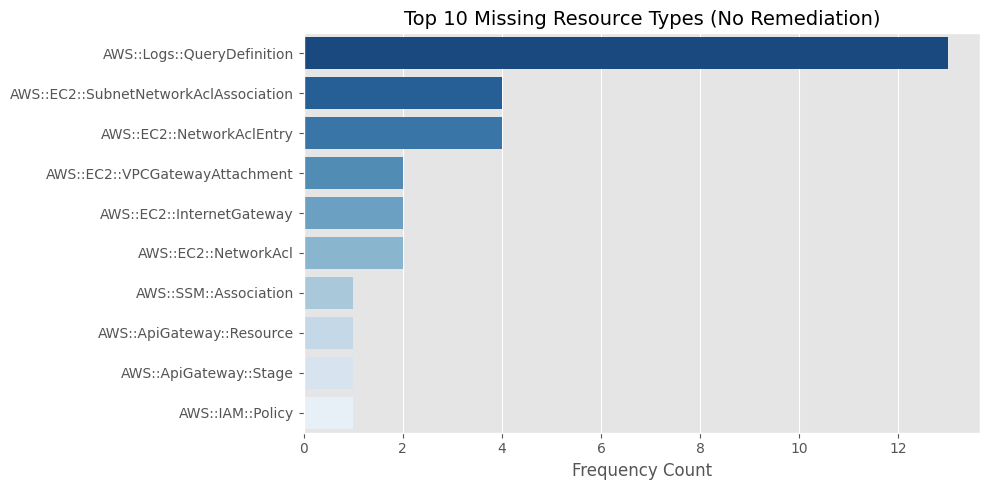

/var/folders/mr/k47n2bks0fs1y0cmq922vqbh0000gn/T/ipykernel_97047/1164442205.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_extra, y='Resource Type', x='Frequency', palette='Oranges_r')


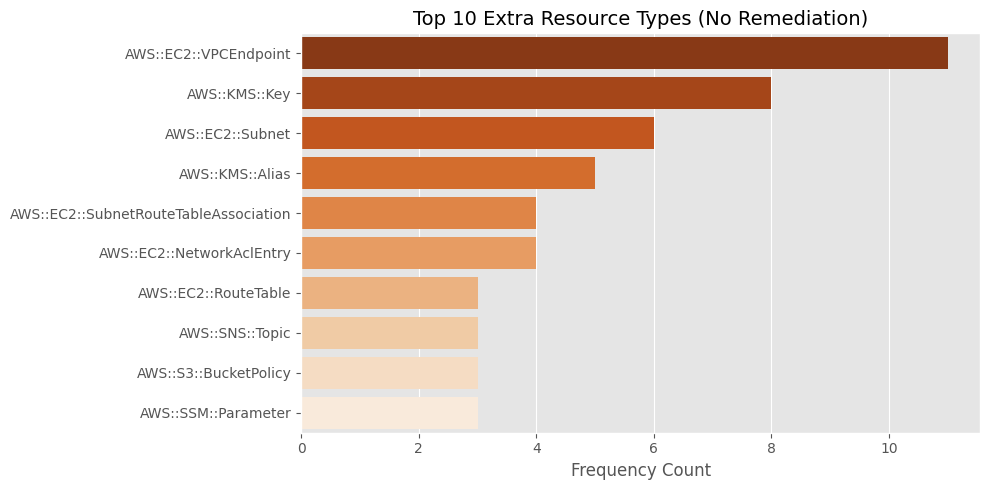

In [17]:
for model_name, df in merged_dataframes.items():
    missing_counter = Counter()
    extra_counter = Counter()
    
    # Parse semicolon-separated missing resources
    if 'missing_resource_types' in df.columns:
        for items in df['missing_resource_types'].dropna():
            for item in str(items).split(';'):
                if item.strip():
                    missing_counter[item.strip()] += 1
                    
    # Parse semicolon-separated extra resources
    if 'extra_resource_types' in df.columns:
        for items in df['extra_resource_types'].dropna():
            for item in str(items).split(';'):
                if item.strip():
                    extra_counter[item.strip()] += 1
                    
    top_missing = pd.DataFrame(missing_counter.most_common(10), columns=['Resource Type', 'Frequency'])
    top_extra = pd.DataFrame(extra_counter.most_common(10), columns=['Resource Type', 'Frequency'])
    
    # Plot Top Missing
    if not top_missing.empty:
        plt.figure(figsize=(10, 5))
        sns.barplot(data=top_missing, y='Resource Type', x='Frequency', palette='Blues_r')
        plt.title(f'Top 10 Missing Resource Types ({model_name})', fontsize=14)
        plt.xlabel('Frequency Count')
        plt.ylabel('')
        plt.tight_layout()
        plt.show()
        
    # Plot Top Extra
    if not top_extra.empty:
        plt.figure(figsize=(10, 5))
        sns.barplot(data=top_extra, y='Resource Type', x='Frequency', palette='Oranges_r')
        plt.title(f'Top 10 Extra Resource Types ({model_name})', fontsize=14)
        plt.xlabel('Frequency Count')
        plt.ylabel('')
        plt.tight_layout()
        plt.show()

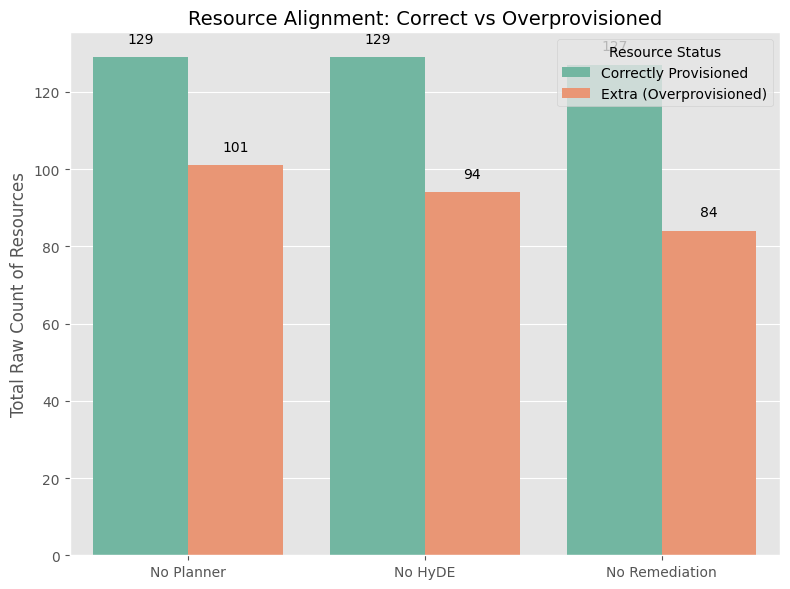

In [18]:
overprovisioning_data = []

for model_name, df in merged_dataframes.items():
    if 'extra_resources' in df.columns and 'correct_resources' in df.columns:
        total_extra = df['extra_resources'].sum()
        total_correct = df['correct_resources'].sum()
        
        overprovisioning_data.append({
            'Model': model_name, 
            'Resource Status': 'Correctly Provisioned', 
            'Total': total_correct
        })
        overprovisioning_data.append({
            'Model': model_name, 
            'Resource Status': 'Extra (Overprovisioned)', 
            'Total': total_extra
        })

if overprovisioning_data:
    over_df = pd.DataFrame(overprovisioning_data)
    
    plt.figure(figsize=(8, 6))
    sns.barplot(data=over_df, x='Model', y='Total', hue='Resource Status', palette='Set2')
    plt.title('Resource Alignment: Correct vs Overprovisioned', fontsize=14)
    plt.ylabel('Total Raw Count of Resources', fontsize=12)
    plt.xlabel('')
    
    # Add data labels
    for p in plt.gca().patches:
        height = p.get_height()
        if height > 0:
            plt.gca().text(p.get_x() + p.get_width()/2., height + 3, f'{int(height)}', 
                           ha='center', va='bottom', fontsize=10)
            
    plt.tight_layout()
    plt.show()
else:
    print("Could not find 'extra_resources' or 'correct_resources' columns to plot overprovisioning.")

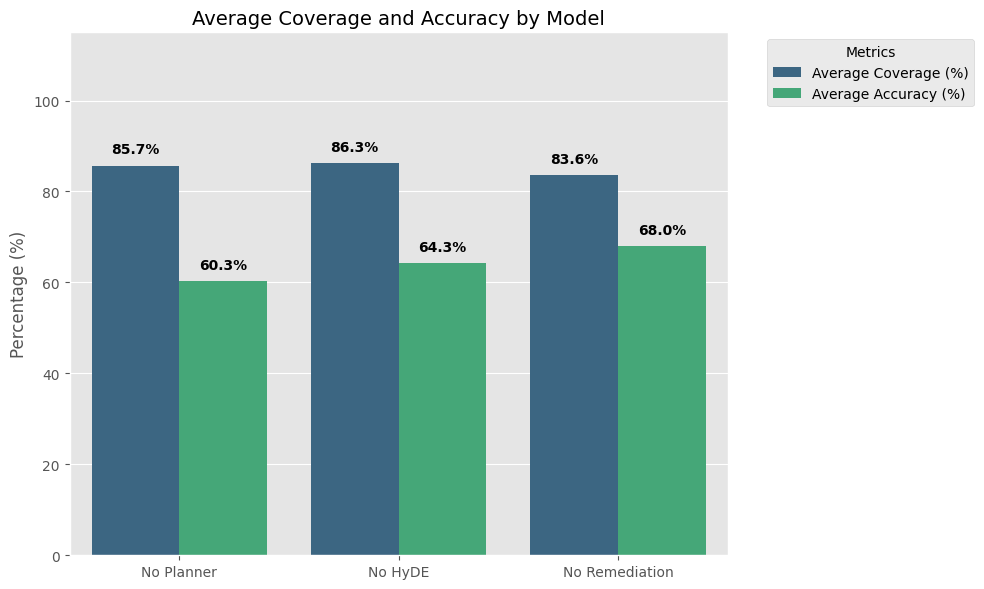

In [19]:
# %%
# Calculate and visualize average coverage and accuracy percentages
avg_metrics_data = []

for model_name, df in merged_dataframes.items():
    if 'coverage_pct' in df.columns and 'accuracy_pct' in df.columns:
        # Calculate the mean for coverage and accuracy, ignoring NaNs
        avg_coverage = df['coverage_pct'].mean()
        avg_accuracy = df['accuracy_pct'].mean()
        
        # Append data in a long format suitable for Seaborn
        avg_metrics_data.extend([
            {'Model': model_name, 'Metric': 'Average Coverage (%)', 'Value': avg_coverage},
            {'Model': model_name, 'Metric': 'Average Accuracy (%)', 'Value': avg_accuracy}
        ])

if avg_metrics_data:
    avg_df = pd.DataFrame(avg_metrics_data)
    
    plt.figure(figsize=(10, 6))
    sns.barplot(data=avg_df, x='Model', y='Value', hue='Metric', palette='viridis')
    
    plt.title('Average Coverage and Accuracy by Model', fontsize=14)
    plt.ylabel('Percentage (%)', fontsize=12)
    plt.xlabel('')
    plt.ylim(0, 115)  # Leave headroom for the data labels
    
    # Add numerical labels to the top of each bar
    for p in plt.gca().patches:
        height = p.get_height()
        if pd.notna(height) and height > 0:
            plt.gca().text(
                p.get_x() + p.get_width() / 2., 
                height + 2, 
                f'{height:.1f}%', 
                ha='center', 
                va='bottom', 
                fontsize=10, 
                fontweight='bold'
            )
            
    # Move legend outside the plot for better visibility
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Metrics")
    plt.tight_layout()
    plt.show()
else:
    print("Could not find 'coverage_pct' or 'accuracy_pct' columns in the provided dataframes.")